In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

In [2]:
df = pd.read_csv('Merged_SoilMoisture_Data.csv')

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Points: {df['Point_ID'].nunique()}  |  Dates: {df['Date'].nunique()}")

Loaded: 401 rows × 17 columns
Points: 100  |  Dates: 22


In [4]:
def engineer_features(df):
    df = df.copy()
 
    #  Temporal features (captures seasonal SM cycle) 
    df['month']     = df['Date'].dt.month
    df['doy']       = df['Date'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
 
    #  Fix 3 missing SAR values (spatial median per point) 
    for col in ['VV_500m', 'VH_500m', 'Angle_500m']:
        null_mask = df[col].isnull()
        if null_mask.sum() > 0:
            fill = df.groupby('Point_ID')[col].transform('median')
            df.loc[null_mask, col] = fill[null_mask]
 
    #  SAR physics features 
    df['VV_linear']  = 10 ** (df['VV_500m'] / 10)   # dB → linear
    df['VH_linear']  = 10 ** (df['VH_500m'] / 10)
    df['VV_VH_diff'] = df['VV_500m'] - df['VH_500m']
 
    #  Terrain interaction features 
    df['slope_elev']  = df['Elevation_m'] / (df['Slope'] + 0.1)
    df['rough_slope'] = df['Roughness'] * df['Slope']
 
    df['VV_x_season'] = df['VV_linear'] * df['month_sin']
    df['VH_x_season'] = df['VH_linear'] * df['month_sin']
    df['VV_x_cos']    = df['VV_linear'] * df['month_cos']
    df['VH_x_cos']    = df['VH_linear'] * df['month_cos']
    df['sin_doy'] = np.sin(2*np.pi*df['doy']/365)
    df['cos_doy'] = np.cos(2*np.pi*df['doy']/365)
    # Dual polarization power
    df['total_power'] = df['VV_linear'] + df['VH_linear']

    # Polarization entropy proxy
    df['pol_entropy'] = -( (df['VV_linear']/(df['VV_linear']+df['VH_linear'])) * 
                        np.log(df['VV_linear']/(df['VV_linear']+df['VH_linear'])) )
    df['northness']      = np.cos(np.radians(df['Aspect']))
    df['eastness']       = np.sin(np.radians(df['Aspect']))
 
    return df
 
df = engineer_features(df)
 
#FEATURES = [
    # SAR backscatter (raw + linear)
 #   'VV_500m', 'VH_500m', 'Angle_500m',
  #  'VV_linear', 'VH_linear', 'VV_VH_diff',
    # Polarimetric indices
   # 'CR=VH/VV', 'RVI', 'RPI=VV/VH', 'NDPI=(VV-VH)/(VV+VH)', 'MPI',
    # Terrain
   # 'Elevation_m', 'Slope', 'Aspect', 'Roughness',
   # 'slope_elev', 'rough_slope',
    # Temporal
   # 'doy','VV_x_season',
   # 'VH_x_season',
   # 'VV_x_cos',   
   # 'VH_x_cos','month_sin', 'month_cos' ]   
 
    

 
#X = df[FEATURES].copy()
#y = df['Observed_SM'].copy()

In [11]:
import numpy as np
import pandas as pd
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# ── FEATURES ────────────────────────────────────────────────────────────────

FEATURES = [
    'doy',
    'VV_500m', 'VH_500m', 'Angle_500m',
    'VV_linear', 'VH_linear', 'VV_VH_diff',
    'CR=VH/VV', 'RVI', 'NDPI=(VV-VH)/(VV+VH)', 'MPI',
    'Elevation_m', 'Slope', 'Roughness',
    'slope_elev', 'rough_slope',
    'VV_x_season', 'VH_x_season', 'VV_x_cos', 'VH_x_cos',
    'sin_doy', 'cos_doy', 'pol_entropy', 'northness', 'eastness'
]

# ── EXTRA INTERACTION FEATURES ──────────────────────────────────────────────

df['VV_x_elev']      = df['VV_500m']    * df['Elevation_m']
df['RVI_x_slope']    = df['RVI']        * df['Slope']
df['CR_x_doy']       = df['CR=VH/VV']  * df['sin_doy']

df['VV_rolling_std']  = df.groupby('Point_ID')['VV_500m'].transform(
                            lambda x: x.rolling(3, min_periods=1).std()).fillna(0)
df['VH_rolling_mean'] = df.groupby('Point_ID')['VH_500m'].transform(
                            lambda x: x.rolling(3, min_periods=1).mean())

EXTRA = ['VV_x_elev', 'RVI_x_slope', 'CR_x_doy', 'VV_rolling_std', 'VH_rolling_mean']

ALL_FEATURES = FEATURES + EXTRA

X = df[imp_shapfeatures].copy()
y = df['Observed_SM'].copy()


# ── RANDOM TRAIN / TEST SPLIT (80/20) ───────────────────────────────────────

X_train_df, X_test_df, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_df = X_train_df.reset_index(drop=True)
y_train_s  = y_train_s.reset_index(drop=True)
X_test_df  = X_test_df.reset_index(drop=True)
y_test_s   = y_test_s.reset_index(drop=True)

scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_df)
X_test_sc  = scaler.transform(X_test_df)

y_train = y_train_s.values
y_test  = y_test_s.values

kf = KFold(n_splits=5, shuffle=True, random_state=42)


# ── METRICS ──────────────────────────────────────────────────────────────────

def full_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    r    = np.corrcoef(y_true, y_pred)[0, 1]
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    print(f"  R²   : {r2:.4f}")
    print(f"  R    : {r:.4f}")
    print(f"  RMSE : {rmse:.4f} m³/m³")
    print(f"  MAE  : {mae:.4f} m³/m³")
    print(f"  Bias : {bias:.4f} m³/m³")
    return dict(r2=r2, r=r, rmse=rmse, mae=mae, bias=bias)


# ── OPTUNA — XGBoost ─────────────────────────────────────────────────────────

print("Tuning XGBoost with Optuna...")

def xgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1200),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        subsample         = trial.suggest_float('subsample', 0.3, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.3, 1.0),
        colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.3, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        gamma             = trial.suggest_float('gamma', 0.0, 2.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda        = trial.suggest_float('reg_lambda', 0.5, 10.0),
        max_bin           = trial.suggest_int('max_bin', 128, 512),
        objective         = 'reg:pseudohubererror',
        tree_method       = 'hist',
        random_state      = 42,
        n_jobs            = -1,
    )

    fold_scores = []
    for tr_idx, val_idx in kf.split(X_train_sc):
        X_tr,  X_val = X_train_sc[tr_idx], X_train_sc[val_idx]
        y_tr,  y_val = y_train[tr_idx],    y_train[val_idx]

        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr, verbose=False)
        fold_scores.append(r2_score(y_val, model.predict(X_val)))

    return np.mean(fold_scores)

study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_xgb.optimize(xgb_objective, n_trials=200, show_progress_bar=True)

print(f"\nXGB best CV R² : {study_xgb.best_value:.4f}")
print(f"XGB best params: {study_xgb.best_params}")


# ── OPTUNA — ExtraTrees ──────────────────────────────────────────────────────

print("\nTuning ExtraTrees with Optuna...")

def et_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 700),
        max_depth         = trial.suggest_int('max_depth', 3, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 15),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        bootstrap         = trial.suggest_categorical('bootstrap', [True, False]),
    )

    fold_scores = []
    for tr_idx, val_idx in kf.split(X_train_sc):
        X_tr,  X_val = X_train_sc[tr_idx], X_train_sc[val_idx]
        y_tr,  y_val = y_train[tr_idx],    y_train[val_idx]

        model = ExtraTreesRegressor(**params, criterion='friedman_mse', random_state=42, n_jobs=-1)
        model.fit(X_tr, y_tr)
        fold_scores.append(r2_score(y_val, model.predict(X_val)))

    return np.mean(fold_scores)

study_et = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_et.optimize(et_objective, n_trials=200, show_progress_bar=True)

print(f"\nET  best CV R² : {study_et.best_value:.4f}")
print(f"ET  best params: {study_et.best_params}")


# ── OPTUNA — LightGBM ────────────────────────────────────────────────────────

print("\nTuning LightGBM with Optuna...")

def lgbm_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1200),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 150),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        subsample         = trial.suggest_float('subsample', 0.3, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.3, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda        = trial.suggest_float('reg_lambda', 0.5, 10.0),
        subsample_freq    = 1,
    )

    fold_scores = []
    for tr_idx, val_idx in kf.split(X_train_sc):
        X_tr,  X_val = X_train_sc[tr_idx], X_train_sc[val_idx]
        y_tr,  y_val = y_train[tr_idx],    y_train[val_idx]

        model = LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
        model.fit(X_tr, y_tr)
        fold_scores.append(r2_score(y_val, model.predict(X_val)))

    return np.mean(fold_scores)

study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_lgbm.optimize(lgbm_objective, n_trials=200, show_progress_bar=True)

print(f"\nLGBM best CV R² : {study_lgbm.best_value:.4f}")
print(f"LGBM best params : {study_lgbm.best_params}")


# ── TRAIN FINAL MODELS ───────────────────────────────────────────────────────

best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update(dict(
    objective   = 'reg:squarederror',
    tree_method = 'hist',
    random_state= 42,
    n_jobs      = -1,
))

best_et_params   = study_et.best_params.copy()
best_lgbm_params = study_lgbm.best_params.copy()

best_xgb  = XGBRegressor(**best_xgb_params)
best_et   = ExtraTreesRegressor(**best_et_params, criterion='friedman_mse',
                                 random_state=42, n_jobs=-1)
best_lgbm = LGBMRegressor(**best_lgbm_params, random_state=42,
                           n_jobs=-1, verbose=-1)

best_xgb.fit(X_train_sc,  y_train, verbose=False)
best_et.fit(X_train_sc,   y_train)
best_lgbm.fit(X_train_sc, y_train)


# ── STACKING META-LEARNER ────────────────────────────────────────────────────

print("\nBuilding stacking ensemble...")

xgb_oof  = cross_val_predict(best_xgb,  X_train_sc, y_train, cv=kf)
et_oof   = cross_val_predict(best_et,   X_train_sc, y_train, cv=kf)
lgbm_oof = cross_val_predict(best_lgbm, X_train_sc, y_train, cv=kf)

stack_train = np.column_stack([xgb_oof, et_oof, lgbm_oof])
stack_test  = np.column_stack([
    best_xgb.predict(X_test_sc),
    best_et.predict(X_test_sc),
    best_lgbm.predict(X_test_sc)
])

meta = RidgeCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0])
meta.fit(stack_train, y_train)

print(f"Meta-learner weights — XGB: {meta.coef_[0]:.3f}  "
      f"ET: {meta.coef_[1]:.3f}  LGBM: {meta.coef_[2]:.3f}")


# ── EVALUATE ─────────────────────────────────────────────────────────────────

train_pred = meta.predict(stack_train)
test_pred  = meta.predict(stack_test)

train_m = full_metrics(y_train, train_pred, "TRAIN")
test_m  = full_metrics(y_test,  test_pred,  "TEST  (random 20% holdout)")

# Individual model scores for comparison
print("\n── Individual Model Test Scores ──")
full_metrics(y_test, best_xgb.predict(X_test_sc),  "XGBoost alone")
full_metrics(y_test, best_et.predict(X_test_sc),   "ExtraTrees alone")
full_metrics(y_test, best_lgbm.predict(X_test_sc), "LightGBM alone")


# ── 5-FOLD CV ON TRAINING DATA ───────────────────────────────────────────────

print(f"\n{'─'*40}")
print(f"  5-FOLD CV (training data)")
print(f"{'─'*40}")

fold_r2, fold_rmse, fold_mae = [], [], []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_sc), 1):
    X_tr,  X_val = X_train_sc[tr_idx], X_train_sc[val_idx]
    y_tr,  y_val = y_train[tr_idx],    y_train[val_idx]

    m_xgb  = XGBRegressor(**best_xgb_params)
    m_et   = ExtraTreesRegressor(**best_et_params, criterion='friedman_mse',
                                  random_state=42, n_jobs=-1)
    m_lgbm = LGBMRegressor(**best_lgbm_params, random_state=42,
                            n_jobs=-1, verbose=-1)

    m_xgb.fit(X_tr,  y_tr, verbose=False)
    m_et.fit(X_tr,   y_tr)
    m_lgbm.fit(X_tr, y_tr)

    s_tr  = np.column_stack([m_xgb.predict(X_tr),  m_et.predict(X_tr),  m_lgbm.predict(X_tr)])
    s_val = np.column_stack([m_xgb.predict(X_val), m_et.predict(X_val), m_lgbm.predict(X_val)])

    m_meta = RidgeCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0])
    m_meta.fit(s_tr, y_tr)
    val_pred = m_meta.predict(s_val)

    f_r2   = r2_score(y_val, val_pred)
    f_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    f_mae  = mean_absolute_error(y_val, val_pred)

    fold_r2.append(f_r2);  fold_rmse.append(f_rmse);  fold_mae.append(f_mae)
    print(f"  Fold {fold}  →  R²={f_r2:.4f}  RMSE={f_rmse:.4f}  MAE={f_mae:.4f}")

print(f"{'─'*40}")
print(f"  Mean  →  R²={np.mean(fold_r2):.4f}  RMSE={np.mean(fold_rmse):.4f}  MAE={np.mean(fold_mae):.4f}")
print(f"  Std   →  R²={np.std(fold_r2):.4f}  RMSE={np.std(fold_rmse):.4f}  MAE={np.std(fold_mae):.4f}")


# ── FEATURE IMPORTANCE ───────────────────────────────────────────────────────

xgb_imp  = pd.Series(best_xgb.feature_importances_,  index=ALL_FEATURES)
et_imp   = pd.Series(best_et.feature_importances_,   index=ALL_FEATURES)
lgbm_imp = pd.Series(best_lgbm.feature_importances_, index=ALL_FEATURES)

# Weighted by meta-learner coefficients (normalised)
w = np.abs(meta.coef_) / np.abs(meta.coef_).sum()
avg_imp = (w[0]*xgb_imp + w[1]*et_imp + w[2]*lgbm_imp).sort_values(ascending=False)

print("\nTop 10 Feature Importances (meta-weighted avg):")
print(avg_imp.head(10).round(4).to_string())

Tuning XGBoost with Optuna...


  0%|          | 0/200 [00:00<?, ?it/s]


XGB best CV R² : 0.4358
XGB best params: {'n_estimators': 942, 'max_depth': 5, 'learning_rate': 0.047561747131362596, 'subsample': 0.7287712968919791, 'colsample_bytree': 0.6610195572149505, 'colsample_bylevel': 0.976050229304184, 'min_child_weight': 4, 'gamma': 0.0005024916195776816, 'reg_alpha': 0.5329729962442913, 'reg_lambda': 5.837576522019549, 'max_bin': 435}

Tuning ExtraTrees with Optuna...


  0%|          | 0/200 [00:00<?, ?it/s]


ET  best CV R² : 0.4340
ET  best params: {'n_estimators': 435, 'max_depth': 15, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 0.8951434591961251, 'bootstrap': True}

Tuning LightGBM with Optuna...


  0%|          | 0/200 [00:00<?, ?it/s]


LGBM best CV R² : 0.4658
LGBM best params : {'n_estimators': 280, 'learning_rate': 0.023481396474305586, 'num_leaves': 35, 'max_depth': 4, 'min_child_samples': 14, 'subsample': 0.9314230560126107, 'colsample_bytree': 0.3873236290268863, 'reg_alpha': 0.0009728897628754809, 'reg_lambda': 5.064418788074533}

Building stacking ensemble...
Meta-learner weights — XGB: 0.270  ET: 0.285  LGBM: 0.480

────────────────────────────────────────
  TRAIN
────────────────────────────────────────
  R²   : 0.4582
  R    : 0.6774
  RMSE : 0.0602 m³/m³
  MAE  : 0.0475 m³/m³
  Bias : -0.0000 m³/m³

────────────────────────────────────────
  TEST  (random 20% holdout)
────────────────────────────────────────
  R²   : 0.4941
  R    : 0.7142
  RMSE : 0.0576 m³/m³
  MAE  : 0.0458 m³/m³
  Bias : 0.0097 m³/m³

── Individual Model Test Scores ──

────────────────────────────────────────
  XGBoost alone
────────────────────────────────────────
  R²   : 0.4850
  R    : 0.7065
  RMSE : 0.0581 m³/m³
  MAE  : 0.0463

ValueError: Length of values (12) does not match length of index (30)

Computing SHAP for XGB...
Computing SHAP for ExtraTrees...
Computing SHAP for LightGBM...

Stack Weights
XGB  : -0.0609
ET   : 0.2732
LGBM : 0.8346

Top 20 Stack SHAP Features
VV_rolling_std    0.162852
cos_doy           0.073083
sin_doy           0.058273
slope_elev        0.056553
VV_x_cos          0.051303
doy               0.050732
Slope             0.049353
Elevation_m       0.047153
VH_x_season       0.046505
VV_x_season       0.040490
VV_x_elev         0.038513
Roughness         0.038317
CR_x_doy          0.034483
rough_slope       0.030754
VH_x_cos          0.029915
northness         0.028776
VV_500m           0.019744
MPI               0.019202
RVI_x_slope       0.018474
Angle_500m        0.014956
dtype: float64


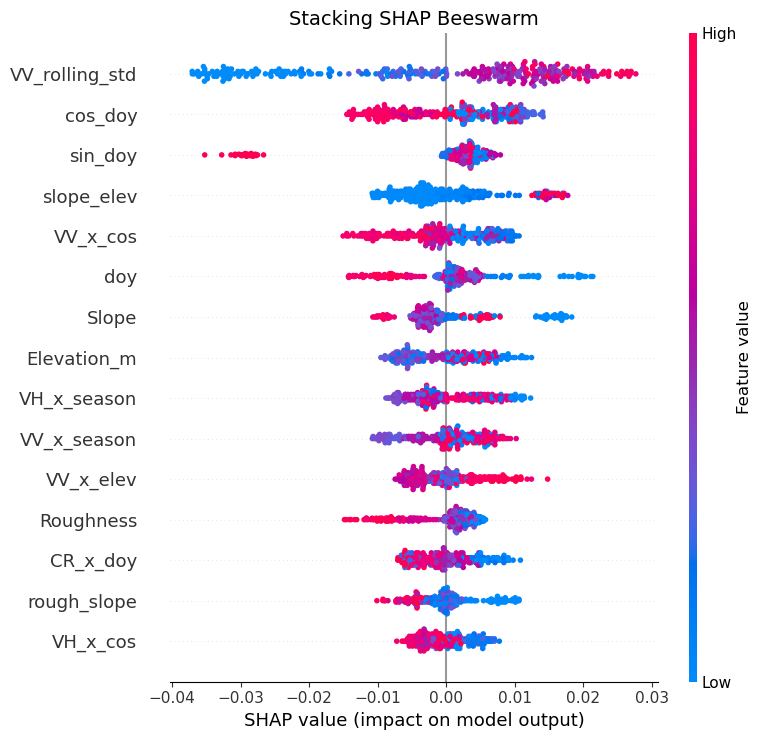

In [9]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# SHAP FOR BASE MODELS
# =====================================================

print("Computing SHAP for XGB...")
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_xgb = explainer_xgb.shap_values(X_train_sc)

print("Computing SHAP for ExtraTrees...")
explainer_et = shap.TreeExplainer(best_et)
shap_et = explainer_et.shap_values(X_train_sc)

print("Computing SHAP for LightGBM...")
explainer_lgbm = shap.TreeExplainer(best_lgbm)
shap_lgbm = explainer_lgbm.shap_values(X_train_sc)

# =====================================================
# META WEIGHTS
# =====================================================

w_xgb  = meta.coef_[0]
w_et   = meta.coef_[1]
w_lgbm = meta.coef_[2]

print("\nStack Weights")
print(f"XGB  : {w_xgb:.4f}")
print(f"ET   : {w_et:.4f}")
print(f"LGBM : {w_lgbm:.4f}")

# =====================================================
# STACK SHAP
# =====================================================

stack_shap = (
      w_xgb  * shap_xgb
    + w_et   * shap_et
    + w_lgbm * shap_lgbm
)

# =====================================================
# IMPORTANCE
# =====================================================

shap_importance = np.abs(stack_shap).mean(axis=0)
shap_importance = shap_importance / shap_importance.sum()

imp_series = pd.Series(
    shap_importance,
    index=ALL_FEATURES
).sort_values(ascending=False)

print("\nTop 20 Stack SHAP Features")
print(imp_series.head(20))

# =====================================================
# BEESWARM
# =====================================================

plt.figure(figsize=(10,7))

shap.summary_plot(
    stack_shap,
    X_train_sc,
    feature_names=ALL_FEATURES,
    max_display=15,
    show=False
)

plt.title("Stacking SHAP Beeswarm", fontsize=14)

plt.tight_layout()
plt.show()



In [10]:
imp_shapfeatures= imp_series.sort_values(ascending=False).head(12).index.tolist()